Make sure modules reload:

In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Generated results and progress files are stored in a directory:

In [24]:
outputFolderName="notebooks/example_CE1"
from run_main import run

To start from scratch remove the directory:

In [20]:
!rm -rf notebooks/example_CE1

/bin/bash: /home/adam/miniconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)


In [25]:
args = dict(
    simduration=50, #duration of simulation run
    simtransient=0, #transient of simulation run
    popSize=16, #population size for optimization
    modelFolder="Worm2D", #folder containing the compiled C++ binary code
    outputFolderName=outputFolderName, #output folder for all results and progress files
    reRand=True, #allow rerunning an identical simulation
    doOrigMuscInput=False, #use standardized NS-muscle connectivity 
    doOrigSRInput=False, #use standardized stretch receptor connectivity 
    overwrite=True, #allow overwrite of output folder contents
    doCPT=True, #load optimization seeds from checkpoint file if found in folder
    checkPointInterval=5, #number of generations between checkpoint file updates
    evoType="EvoCE",#optimization algorithm cost function
    doLegacy=False, #use standardized variable initialization 
    randomInitialState=True, #initialize variables randomly from given seed
    AvgSpeed=0.0001, #parameter for cost function - the target worm speed
)

Run the evolution. Each time it is run, a further 'maxGen' generations will be added to the existing results.

Further generations to be added: 5
Directory 'notebooks/example_CE1' created successfully.
['Worm2D/main_osc', '--randomInitialState', '1', '--AvgSpeed', '0.0001', '--doOrigMuscInput', '0', '--doOrigSRInput', '0', '--doTestRun', '1', '--SRZeroGainsType', '1', '--doLegacy', '0', '-R', '506569', '-p', '30', '-d', '24', '-t', '8', '--maxgens', '5', '-sd', '20', '-st', '0', '--doevol', '1', '-cpt', '5', '--dorandinit', '0', '--donml', '0', '--folder', 'notebooks/example_CE1', '--modelname', 'W2DCE', '--domusc', '0', '-docpt', '1', '--evoType', 'EvoCE']
evotype EvoCE
docpt 1
const from default with size 17
jsonfile notebooks/example_CE1/worm_data_evo.json
jsonfile notebooks/example_CE1/worm_data_evo.json
simrandseed 506569
running simulation sim

Saved plot image to: notebooks/example_CE1/ExampleActivity.png
Simulation
0.0
20.0
40.0
60.0
80.0
100.0
cell ind is  24
cell ind is  25
cell ind is  26
cell ind is  28
cell ind is  29
cell ind is  27
Evolvable
value
0
name
checkDict
['W2DCE_SR_A', 

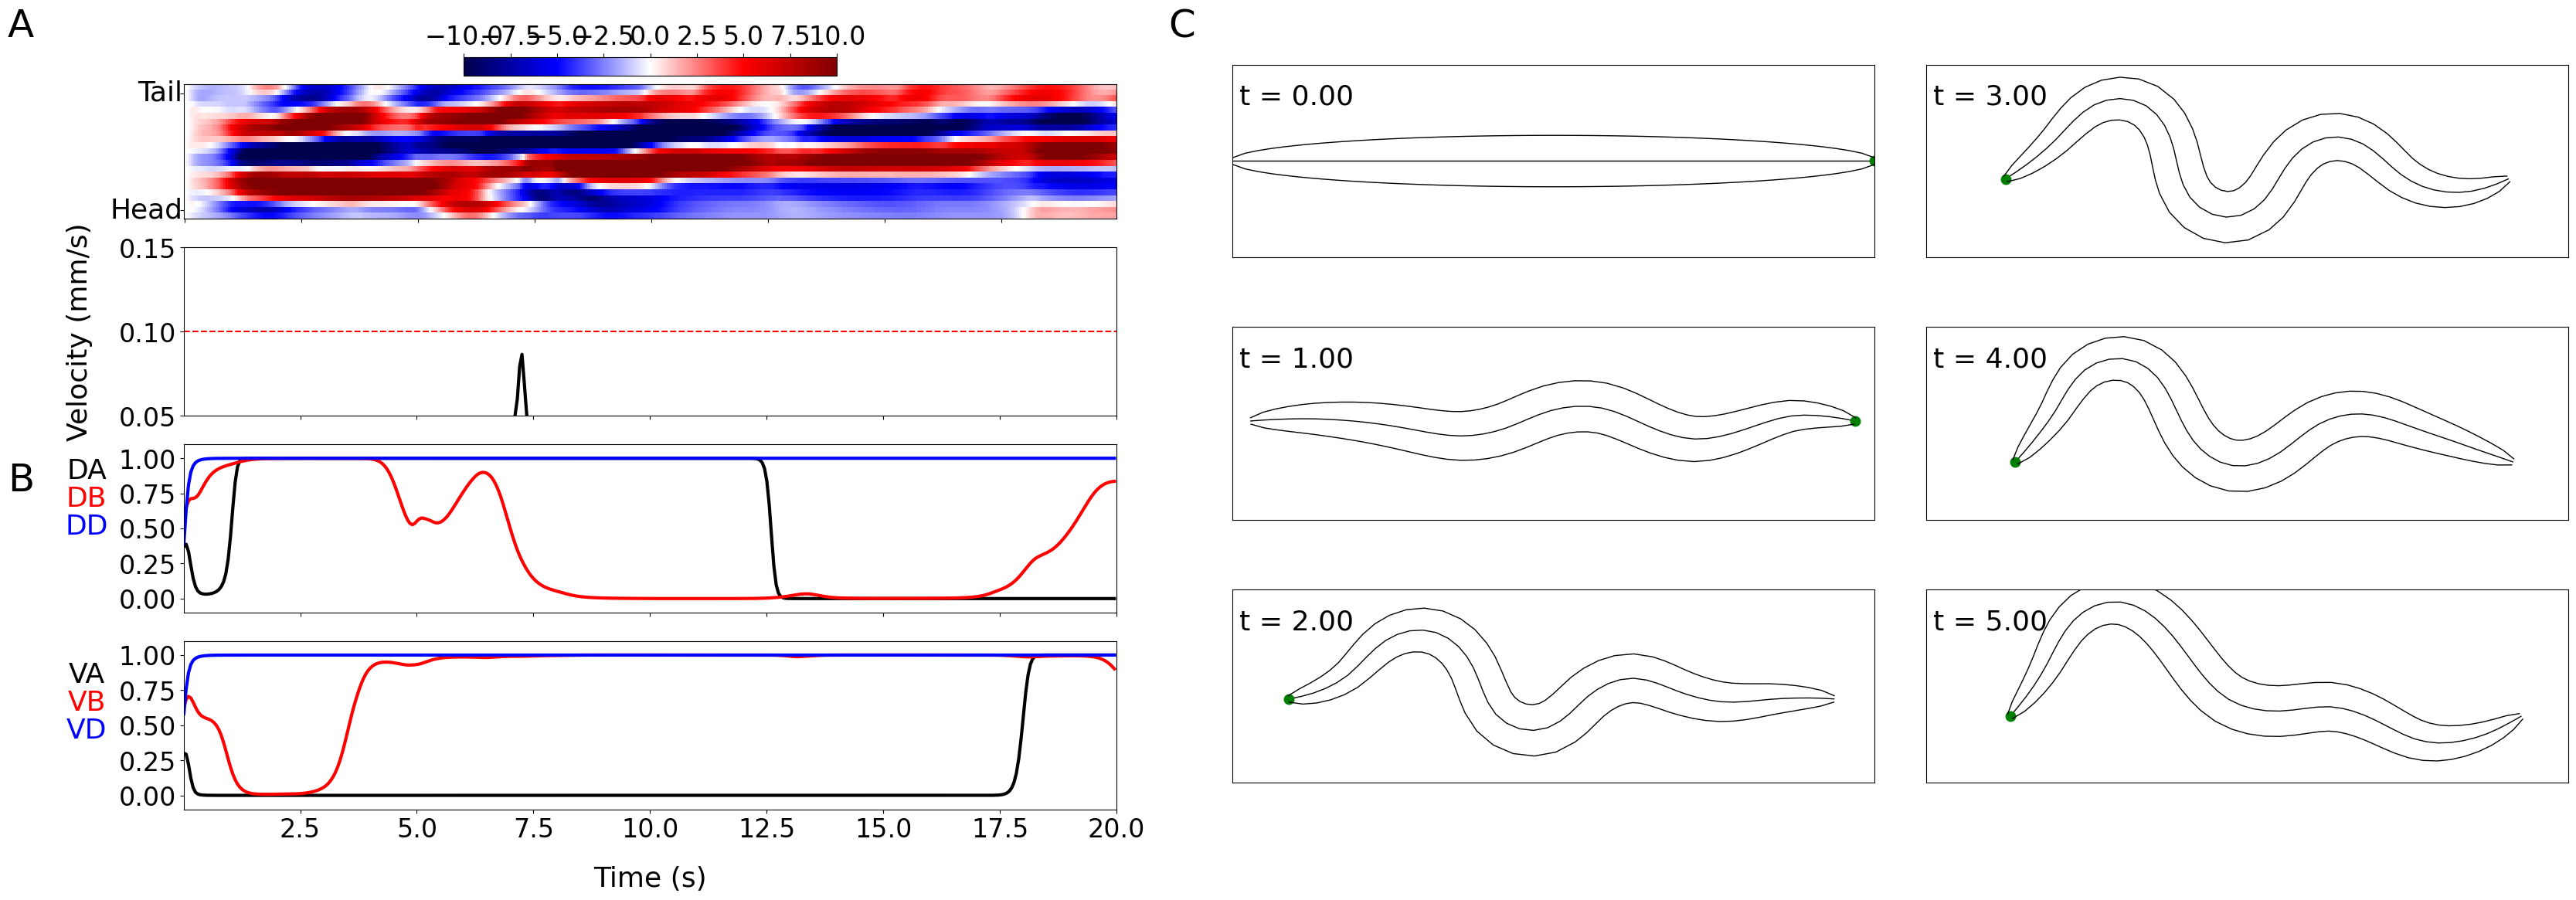

In [22]:
print('Further generations to be added: ' + str(args['maxGens']))
run(**args)

In [13]:
with open(outputFolderName + '/fitness.dat') as f:
    print(f.read())

0 0.9215618669 0.1623033406 0.08017224337
1 0.9393469664 0.1969238789 0.1027110142
2 0.9519386157 0.2407107843 0.1387741692
3 0.9904098874 0.1852284254 0.1240344884
4 0.9904098874 0.243903275 0.1347510392
5 0.9904098874 0.1790028844 0.1188160471



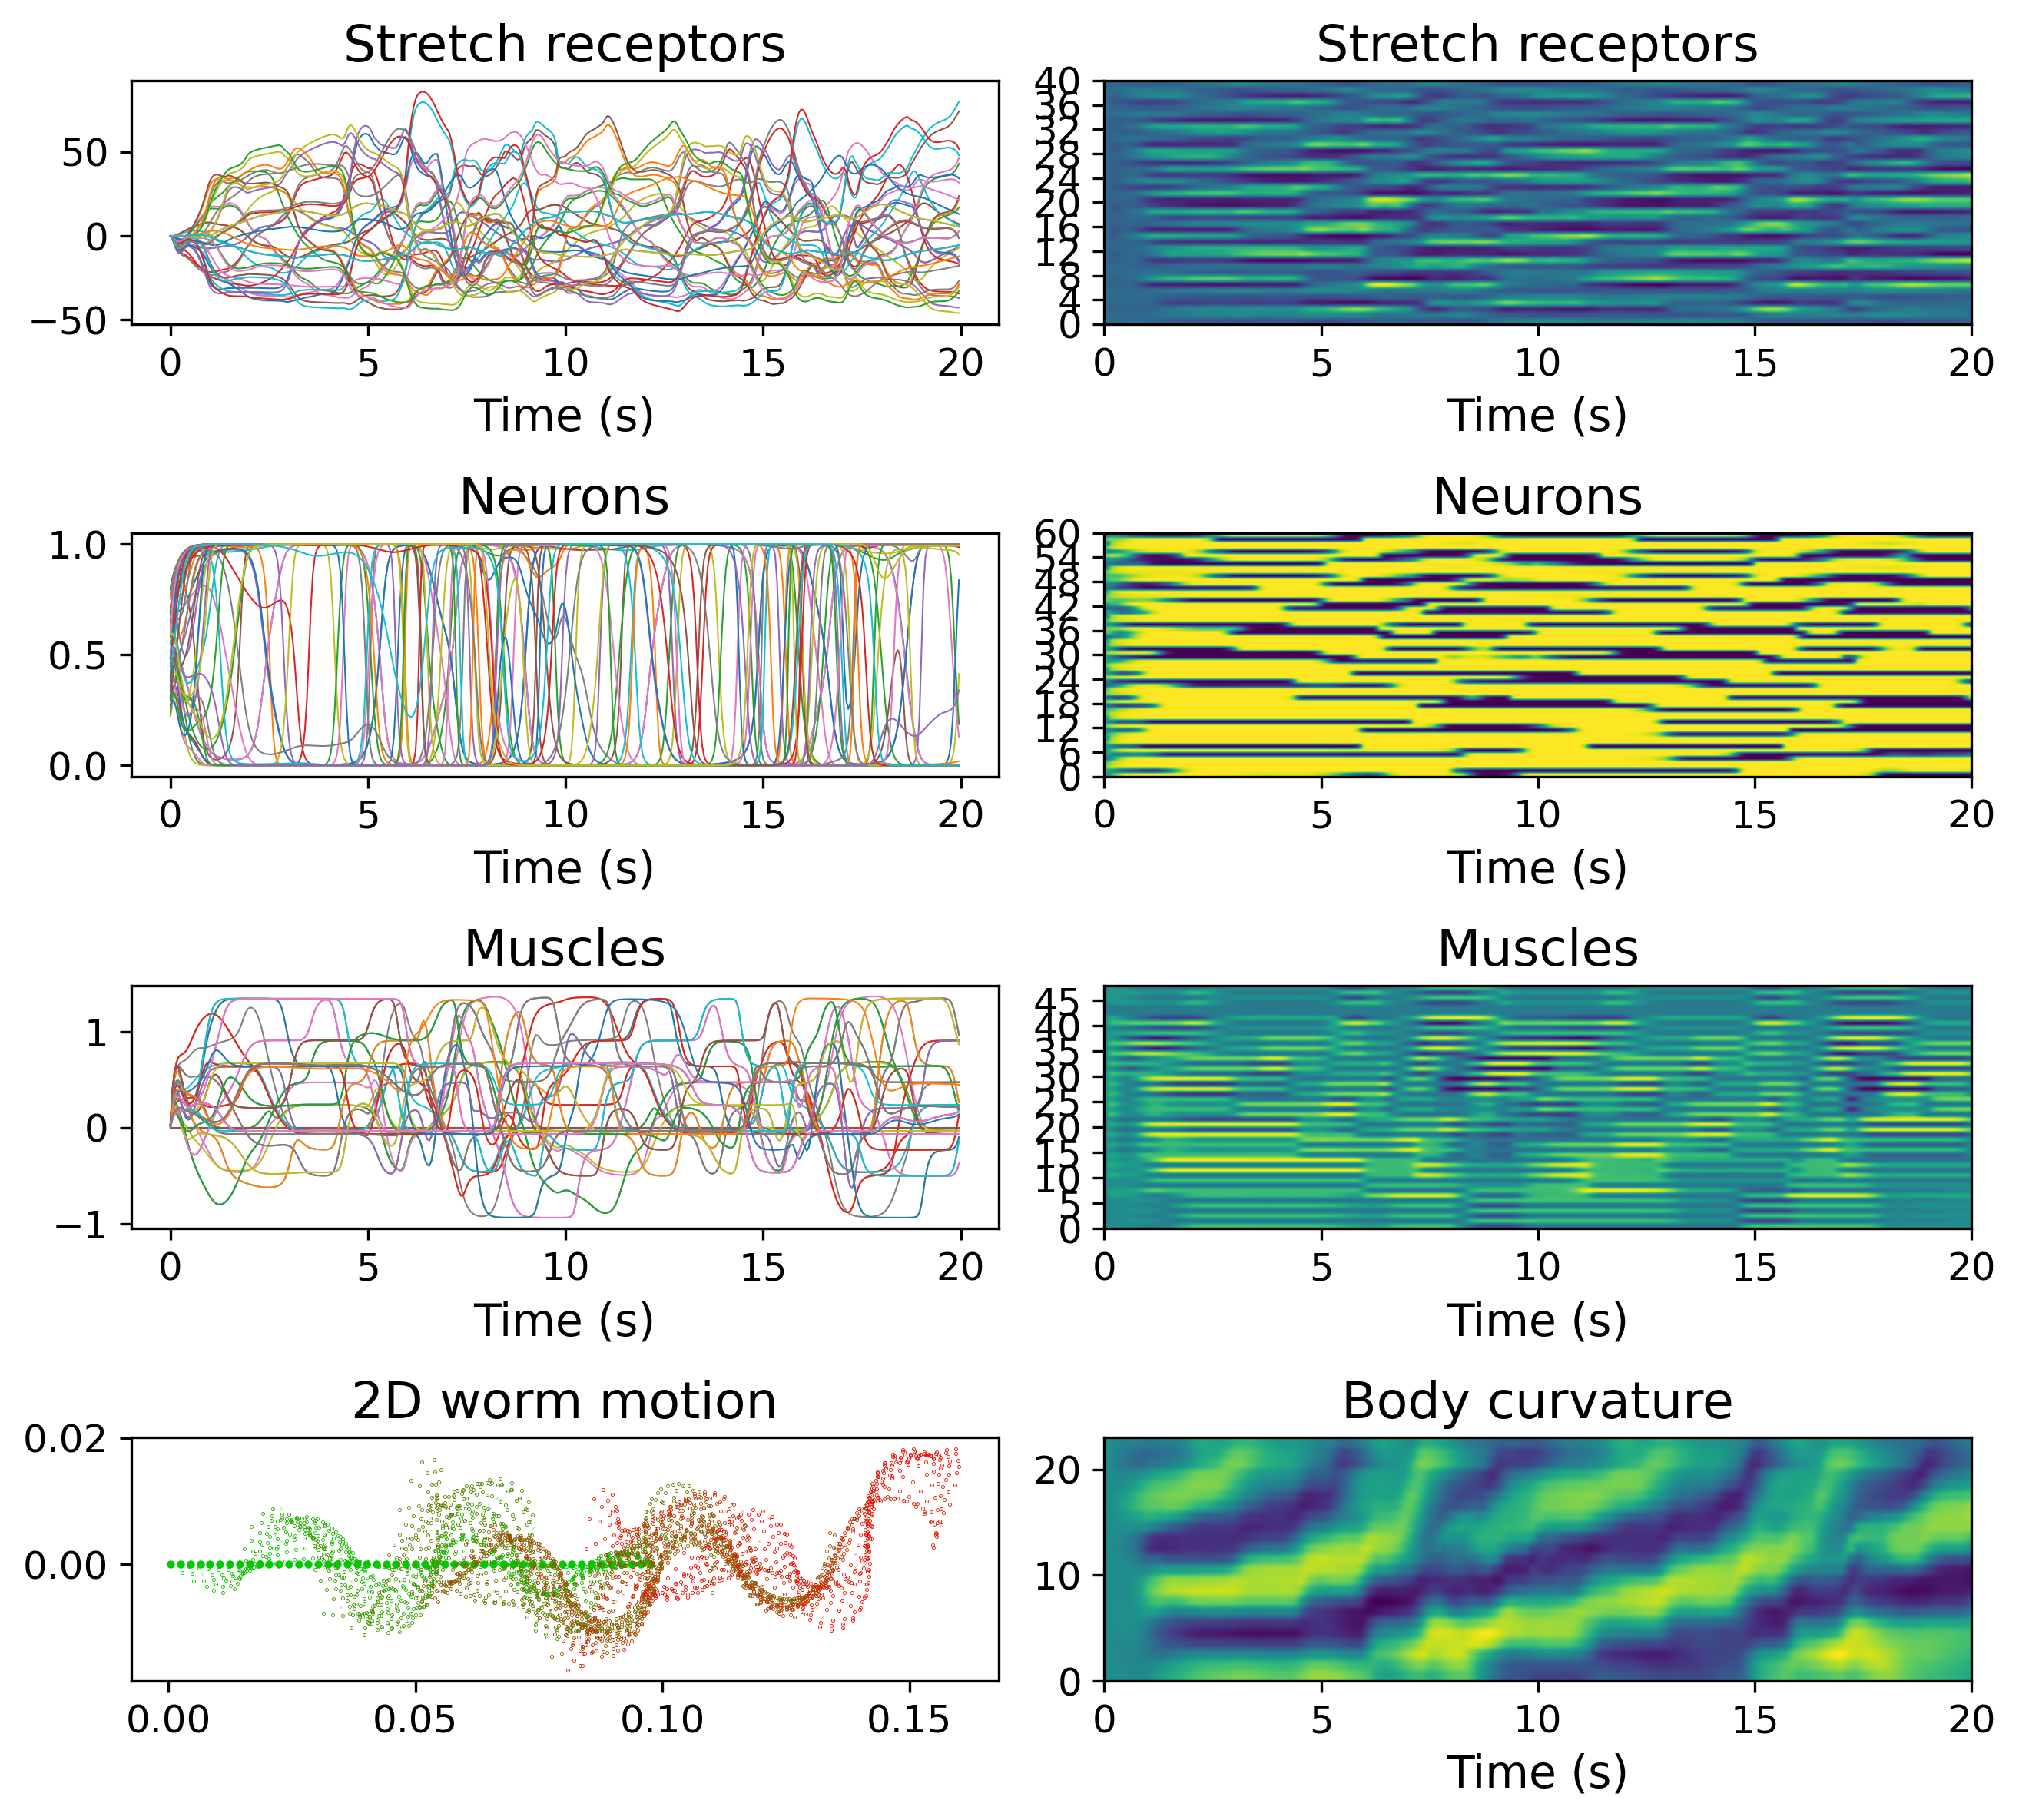

In [18]:
from IPython.display import Image, JSON
Image(filename=outputFolderName + '/ExampleActivity.png')

Initialize the model from the (potentially modified) JSON file using the 'W2DSR' model and increment by five generations.

In [ ]:
args['modelName'] ="W2DSR"
print('Further generations to be added: ' + str(args['maxGens']))
run(**args)

Run a longer simulation of the best phenotype with no further evolution: 

Directory 'notebooks/example_CE1' already exists and the simulation results will be overwritten.
Parameter not found in worm_data.json
Parameter not found in worm_data.json
Parameter not found in worm_data.json
Parameter not found in worm_data.json
['Worm2D/main_osc', '--randomInitialState', '1', '--AvgSpeed', '0.0001', '--doOrigMuscInput', '0', '--doOrigSRInput', '0', '--doTestRun', '1', '--SRZeroGainsType', '1', '--doLegacy', '0', '-R', '2783', '-p', '30', '-d', '24.0', '-t', '8.0', '--maxgens', '5', '-sd', '50', '-st', '0', '--doevol', '0', '-cpt', '5', '--dorandinit', '0', '--donml', '0', '--folder', 'notebooks/example_CE1', '--modelname', 'W2DSR', '--domusc', '0', '-docpt', '1', '--evoType', 'EvoCE']
jsonfile notebooks/example_CE1/worm_data_worm.json
jsonfile notebooks/example_CE1/worm_data_evo.json

Saved plot image to: notebooks/example_CE1/ExampleActivity.png
Simulation
0.0
20.0
40.0
60.0
80.0
100.0
cell ind is  24
cell ind is  25
cell ind is  26
cell ind is  28
cell ind is  29

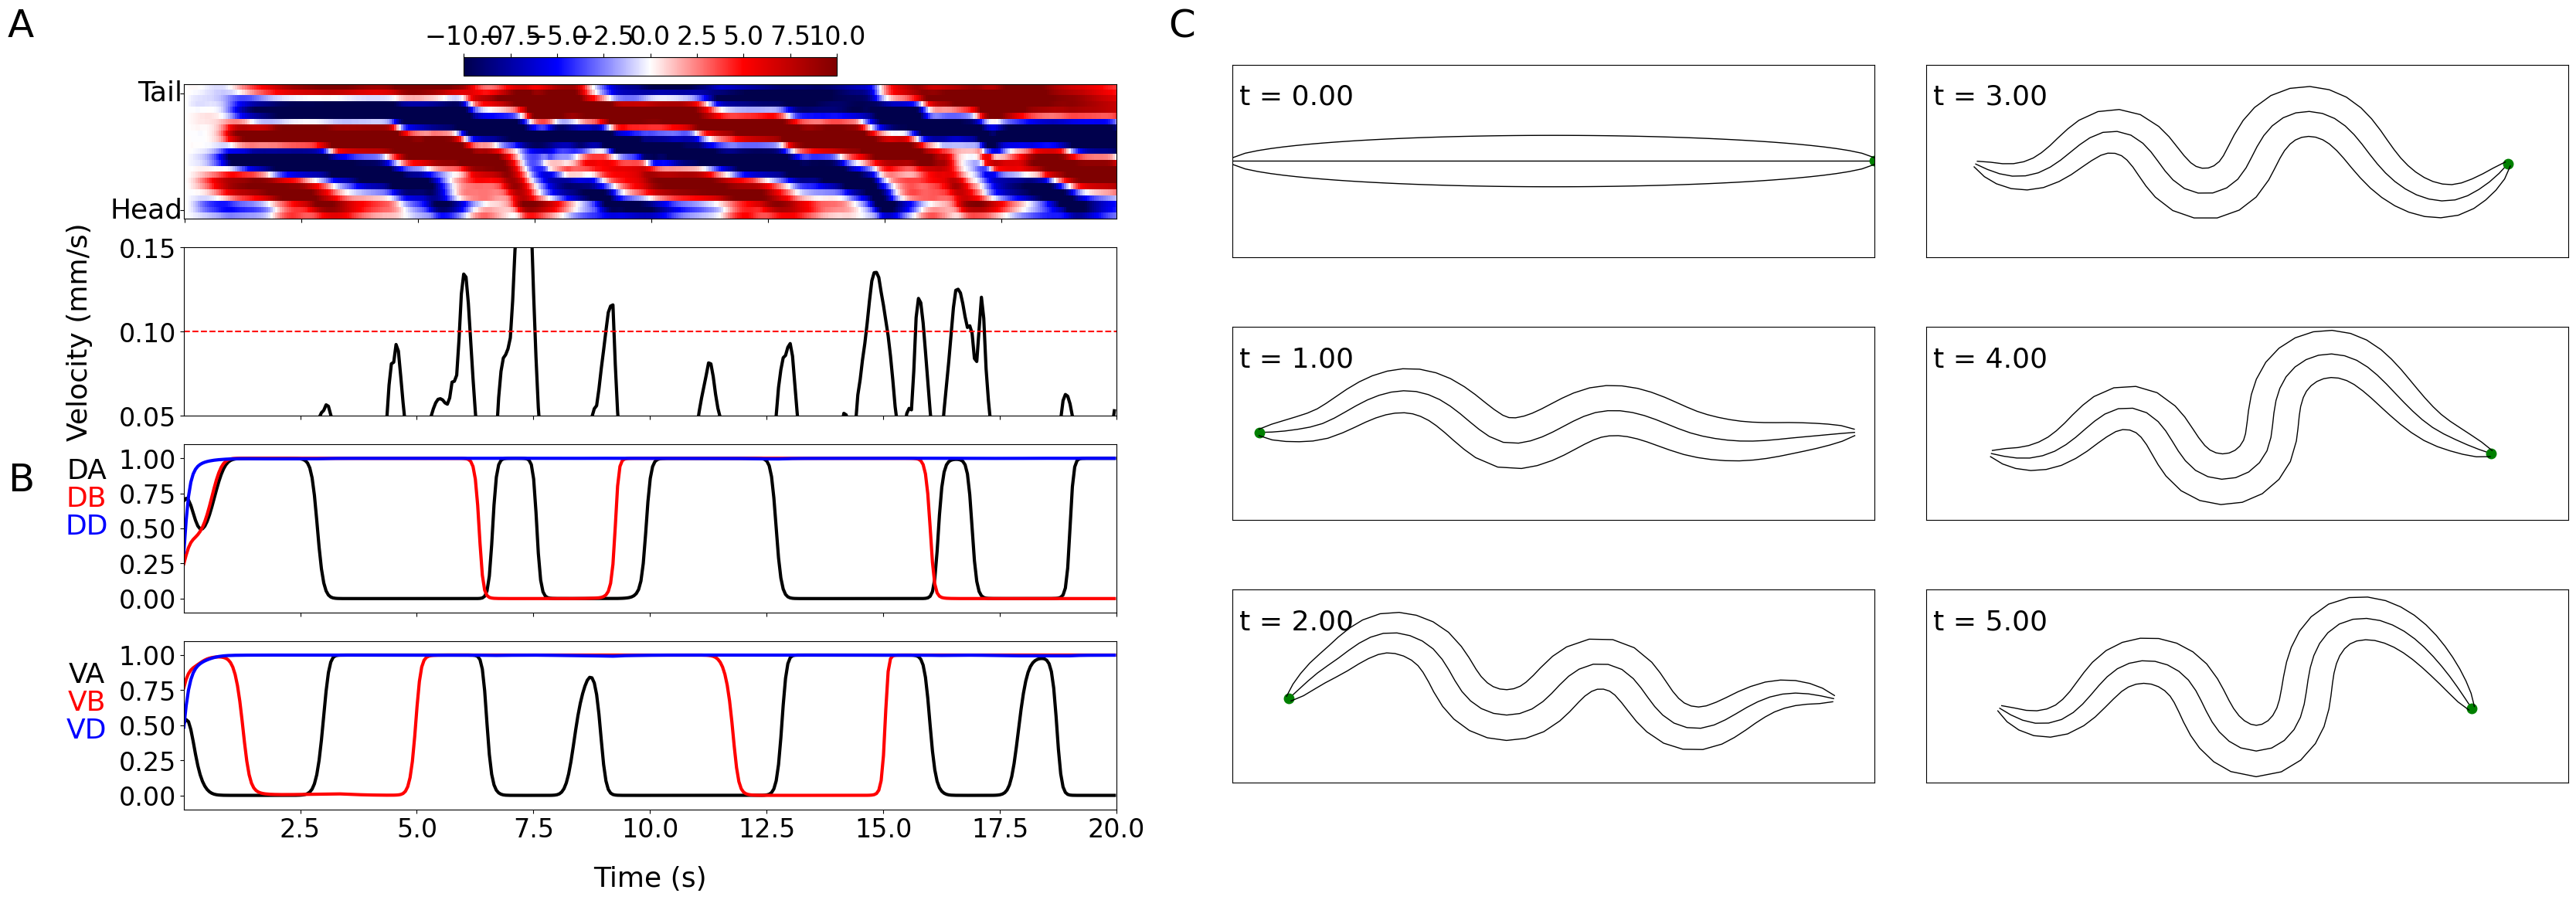

In [17]:
args['RandSeed']=2783
args['reRand']=True
args['doEvol']=False
args['modelName'] = "W2DSR"
args['simduration'] = 50
run(**args)

In [ ]:
import json
with open(outputFolderName + '/worm_data_evo.json') as json_file:
    json_data = json.load(json_file)

In [ ]:
JSON(filename=outputFolderName + '/worm_data_evo.json')

In [ ]:
JSON(filename=outputFolderName + '/worm_data_worm.json')

In [ ]:
with open(outputFolderName + '/worm_data_evo.json', "w") as f:
    json.dump(json_data, f)

In [ ]:
print(json_data['Driving input'])

In [ ]:
print(json_data['input_switcher'])

In [ ]:
print(json_data['Funcable'])

In [ ]:
json_data['input_switcher']['inputInd']=0

In [ ]:
json_data['Funcable']['2']['condval']=0

In [ ]:
with open(outputFolderName + '/worm_data_evo.json') as json_file:
    json_data = json.load(json_file)
print(json_data['Nervous system']['Chemical weights']['value'][1])
json_data['Nervous system']['Chemical weights']['value'][1]['weight'] = 0
print(json_data['Nervous system']['Chemical weights']['value'][1])

In [ ]:
import shutil
shutil.copyfile(outputFolderName + '/worm_data_evo.json', 
                outputFolderName + '/worm_data_evo_orig.json')

In [ ]:
json_data['Nervous system']['Chemical weights']['value'][1]['weight'] = -15.071462336914168
print(json_data['Nervous system']['Chemical weights']['value'][1])